1. overview of the dataset

In [2]:
# === Cell 1: 파일 열고 구조 확인 ===
import h5py
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

# ↓ 본인이 Drive에 올린 위치로 경로를 맞추세요.
#   MyDrive 바로 아래에 올렸으면 이대로, 하위 폴더에 넣었으면 폴더명을 추가하세요.
path = '/content/drive/MyDrive/Colab Notebooks/2017-05-12_batchdata_updated_struct_errorcorrect.mat'

f = h5py.File(path, 'r')
print("최상위 키:", list(f.keys()))

batch = f['batch']
print("batch 안의 키:", list(batch.keys()))

num_cells = batch['summary'].shape[0]
print("셀 개수:", num_cells)

cl = f[batch['cycle_life'][0, 0]][()]
print("첫 셀의 cycle_life:", np.array(cl).flatten()[0])

summary = f[batch['summary'][0, 0]]
print("summary 안의 키:", list(summary.keys()))

Mounted at /content/drive
최상위 키: ['#refs#', '#subsystem#', 'batch', 'batch_date']
batch 안의 키: ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']
셀 개수: 46
첫 셀의 cycle_life: 1190.0
summary 안의 키: ['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']


In [3]:
# === Cell 2: 46개 셀 파싱 → 요약 테이블 ===
import numpy as np
import pandas as pd

num_cells = batch['summary'].shape[0]

cells = {}     # 셀별 상세 (capacity fade 곡선용)
rows = []      # 셀별 요약 (테이블/히스토그램용)

for i in range(num_cells):
    # 수명
    cl = f[batch['cycle_life'][i, 0]][()]
    cycle_life = float(np.array(cl).flatten()[0])

    # 사이클별 시계열
    summ = f[batch['summary'][i, 0]]
    QD  = np.array(summ['QDischarge']).flatten().astype(float)  # 방전용량
    cyc = np.array(summ['cycle']).flatten().astype(float)       # 사이클 번호

    # 충전 정책(프로토콜) 문자열 — 실패해도 넘어가도록 방어
    try:
        raw = np.array(f[batch['policy_readable'][i, 0]][()]).flatten()
        policy = ''.join(chr(int(c)) for c in raw).rstrip('\x00')
    except Exception:
        policy = ''

    cells[i] = {'cycle': cyc, 'QDischarge': QD, 'cycle_life': cycle_life, 'policy': policy}
    rows.append({'cell': i, 'policy': policy, 'cycle_life': cycle_life,
                 'n_cycles': len(cyc),
                 'Q_start': QD[0]  if len(QD) else np.nan,
                 'Q_end':   QD[-1] if len(QD) else np.nan})

df = pd.DataFrame(rows)
print("테이블 크기:", df.shape)
df.head(10)

테이블 크기: (46, 6)


,cell,policy,cycle_life,n_cycles,Q_start,Q_end
0,0,3.6C(80%)-3.6C,1190.0,1189,0.0,1.026210
1,1,3.6C(80%)-3.6C,1179.0,1178,0.0,1.038225
2,2,3.6C(80%)-3.6C,1177.0,1176,0.0,1.043279
3,3,4C(80%)-4C,1226.0,1225,0.0,0.970921
4,4,4C(80%)-4C,1227.0,1226,0.0,1.021960
5,5,4.4C(80%)-4.4C,1074.0,1073,0.0,0.880536
6,6,4.8C(80%)-4.8C,636.0,635,0.0,0.880057
7,7,4.8C(80%)-4.8C,870.0,869,0.0,0.881106
8,8,5.4C(40%)-3.6C,879.0,878,0.0,0.969025
9,9,5.4C(40%)-3.6C,1054.0,1053,0.0,0.880928


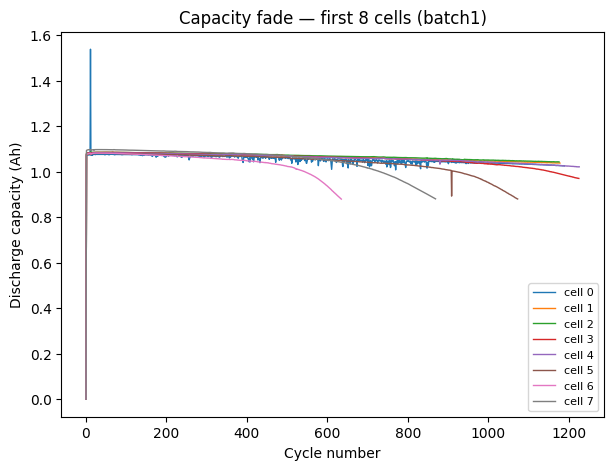

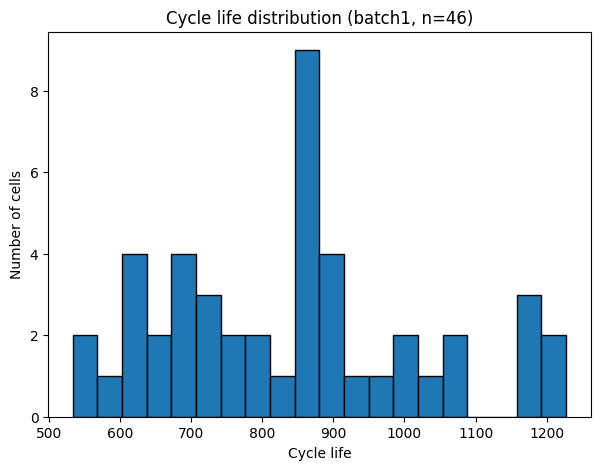

수명(cycle life) 통계:
count      46.000000
mean      844.717391
std       184.629198
min       534.000000
25%       703.250000
50%       858.500000
75%       914.250000
max      1227.000000
Name: cycle_life, dtype: float64


In [4]:
# === Cell 3: EDA — capacity fade + 수명 분포 ===
import matplotlib.pyplot as plt

# (1) capacity fade 곡선 (앞 8개 셀)
plt.figure(figsize=(7, 5))
for i in list(cells.keys())[:8]:
    c = cells[i]
    plt.plot(c['cycle'], c['QDischarge'], lw=1, label=f"cell {i}")
plt.xlabel('Cycle number'); plt.ylabel('Discharge capacity (Ah)')
plt.title('Capacity fade — first 8 cells (batch1)')
plt.legend(fontsize=8); plt.show()

# (2) cycle life 분포
plt.figure(figsize=(7, 5))
plt.hist(df['cycle_life'], bins=20, edgecolor='k')
plt.xlabel('Cycle life'); plt.ylabel('Number of cells')
plt.title(f'Cycle life distribution (batch1, n={len(df)})')
plt.show()

print("수명(cycle life) 통계:")
print(df['cycle_life'].describe())


cycles 안의 키: ['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']
cell 0의 사이클 레코드 수: 1189
Vdlin 길이: 1000 | 범위: 2.0 ~ 3.5


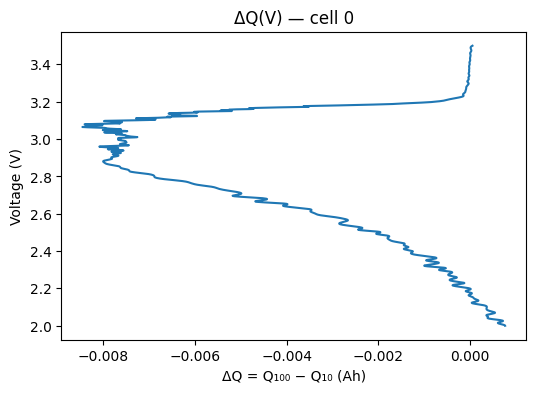

log10(var(ΔQ)): -5.014861042960787


In [5]:
# === Cell 4: cycles 구조 확인 + 첫 셀 ΔQ(V) ===
import numpy as np
import matplotlib.pyplot as plt

i = 0
cell = f[batch['cycles'][i, 0]]
print("cycles 안의 키:", list(cell.keys()))

n_cyc = cell['Qdlin'].shape[0]
print("cell 0의 사이클 레코드 수:", n_cyc)

# 전압 그리드 (Qdlin이 이 전압축 위에 정의됨)
Vdlin = np.array(f[batch['Vdlin'][i, 0]]).flatten()
print("Vdlin 길이:", len(Vdlin), "| 범위:", round(Vdlin.min(),3), "~", round(Vdlin.max(),3))

def get_Qdlin(cell, j):
    # j번째 사이클의 방전용량 곡선 (전압 그리드 위)
    return np.array(f[cell['Qdlin'][j, 0]]).flatten()

c10  = get_Qdlin(cell, 9)    # 약 10번째 사이클
c100 = get_Qdlin(cell, 99)   # 약 100번째 사이클
dQ = c100 - c10

plt.figure(figsize=(6, 4))
plt.plot(dQ, Vdlin)
plt.xlabel('ΔQ = Q₁₀₀ − Q₁₀ (Ah)'); plt.ylabel('Voltage (V)')
plt.title('ΔQ(V) — cell 0')
plt.show()

print("log10(var(ΔQ)):", np.log10(np.var(dQ)))

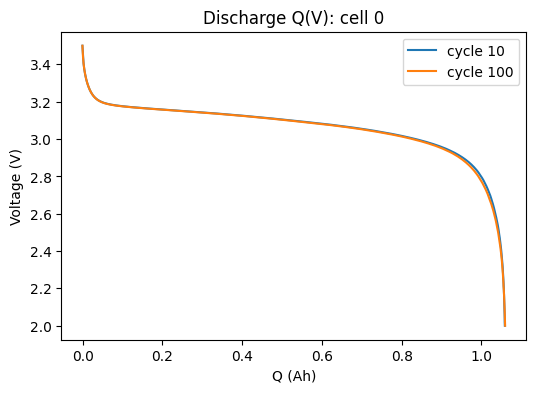

In [6]:
# Q(V) 두 사이클 겹쳐보기 — 교차 확인
plt.figure(figsize=(6, 4))
plt.plot(get_Qdlin(cell, 9),  Vdlin, label='cycle 10')
plt.plot(get_Qdlin(cell, 99), Vdlin, label='cycle 100')
plt.xlabel('Q (Ah)'); plt.ylabel('Voltage (V)')
plt.title('Discharge Q(V): cell 0'); plt.legend(); plt.show()


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54645 (\N{HANGUL SYLLABLE HAEG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49900 (\N{HANGUL SYLLABLE SIM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


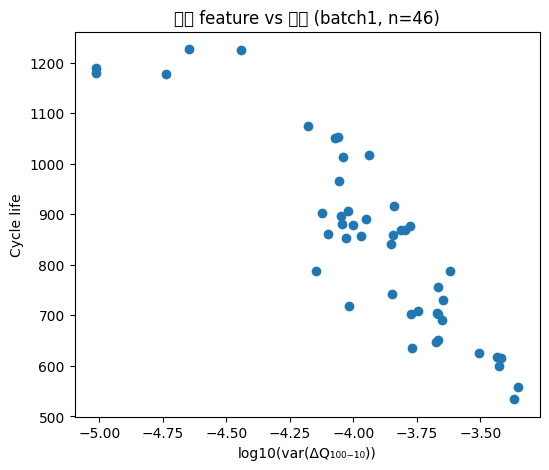

Pearson r (feature vs 수명)       : -0.886
Pearson r (feature vs log10 수명) : -0.868


In [7]:
# === Cell 5: 46개 셀 전부 feature 계산 → 수명과 상관 ===
from scipy.stats import pearsonr

feat_logvar, lifes = [], []
for i in range(num_cells):
    cell_i = f[batch['cycles'][i, 0]]
    Q10  = np.array(f[cell_i['Qdlin'][9,  0]]).flatten()   # ~10번째 사이클
    Q100 = np.array(f[cell_i['Qdlin'][99, 0]]).flatten()   # ~100번째 사이클
    dQ = Q100 - Q10
    feat_logvar.append(np.log10(np.var(dQ)))
    lifes.append(cells[i]['cycle_life'])

feat_logvar = np.array(feat_logvar)
lifes = np.array(lifes)

# 상관 그림
plt.figure(figsize=(6, 5))
plt.scatter(feat_logvar, lifes)
plt.xlabel('log10(var(ΔQ₁₀₀₋₁₀))'); plt.ylabel('Cycle life')
plt.title('핵심 feature vs 수명 (batch1, n=46)')
plt.show()

print(f"Pearson r (feature vs 수명)       : {pearsonr(feat_logvar, lifes)[0]:.3f}")
print(f"Pearson r (feature vs log10 수명) : {pearsonr(feat_logvar, np.log10(lifes))[0]:.3f}")

In [9]:
# === Cell 6: 여러 feature 모아 테이블(X)과 타깃(y) 만들기 ===
import pandas as pd

def cell_features(i):
    cyc  = f[batch['cycles'][i, 0]]
    Q10  = np.array(f[cyc['Qdlin'][9,  0]]).flatten()
    Q100 = np.array(f[cyc['Qdlin'][99, 0]]).flatten()
    dQ = Q100 - Q10

    QD = cells[i]['QDischarge']            # 사이클별 방전용량(summary)
    x  = np.arange(2, 101)                 # 초기 용량감소 기울기 (cycle 2~100)
    y_ = QD[1:100]
    slope = np.polyfit(x[:len(y_)], y_, 1)[0]

    return {
        'logvar_dQ':   np.log10(np.var(dQ)),           # ⭐ 방전곡선 모양 변화(스타)
        'logmin_dQ':   np.log10(np.abs(np.min(dQ))),   # ΔQ 최대 낙폭 크기
        'Qd_100':      QD[99],                          # 100사이클 잔여용량
        'slope_2_100': slope,                           # 초기 용량감소 속도
    }

rows = [dict(cell=i, **cell_features(i), cycle_life=cells[i]['cycle_life'])
        for i in range(num_cells)]
feat_df = pd.DataFrame(rows)

X = feat_df[['logvar_dQ', 'logmin_dQ', 'Qd_100', 'slope_2_100']]
y = feat_df['cycle_life']

print(feat_df.describe().round(3))
feat_df.head()

         cell  logvar_dQ  logmin_dQ  Qd_100  slope_2_100  cycle_life
count  46.000     46.000     46.000  46.000         46.0      46.000
mean   22.500     -3.923     -1.477   1.081         -0.0     844.717
std    13.423      0.378      0.183   0.008          0.0     184.629
min     0.000     -5.015     -2.073   1.060         -0.0     534.000
25%    11.250     -4.053     -1.544   1.077         -0.0     703.250
50%    22.500     -3.851     -1.440   1.082         -0.0     858.500
75%    33.750     -3.668     -1.351   1.085          0.0     914.250
max    45.000     -3.350     -1.189   1.096          0.0    1227.000


,cell,logvar_dQ,logmin_dQ,Qd_100,slope_2_100,cycle_life
0,0,-5.014861,-2.072648,1.075913,-0.000207,1190.0
1,1,-5.013960,-1.958457,1.080630,0.000006,1179.0
2,2,-4.737000,-1.764058,1.084940,0.000010,1177.0
3,3,-4.442613,-1.722149,1.084750,0.000017,1226.0
4,4,-4.647744,-1.855177,1.082646,0.000019,1227.0


Baseline     RMSE= 100.5 cycles   MAPE=  8.8%
ElasticNet   RMSE=  98.8 cycles   MAPE=  8.8%

ElasticNet 5-fold CV RMSE: 85.9 ± 11.6 cycles


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

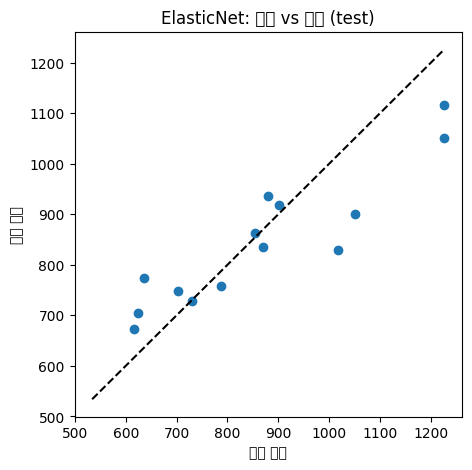

In [10]:
# === Cell 7: ElasticNet 모델 학습 + 평가 ===
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV, LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

X = feat_df[['logvar_dQ', 'logmin_dQ', 'Qd_100', 'slope_2_100']].values
y = feat_df['cycle_life'].values

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)

# 베이스라인: logvar 단일 feature 선형회귀
base = make_pipeline(StandardScaler(), LinearRegression())
base.fit(X_tr[:, [0]], y_tr)
p_base = base.predict(X_te[:, [0]])

# ElasticNet: 4개 feature 전부 (정규화 세기 자동 선택)
enet = make_pipeline(
    StandardScaler(),
    ElasticNetCV(l1_ratio=[.1, .5, .9, 1], alphas=np.logspace(-3, 2, 50),
                 cv=5, max_iter=10000))
enet.fit(X_tr, y_tr)
p_enet = enet.predict(X_te)

def report(name, yt, yp):
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mape = mean_absolute_percentage_error(yt, yp) * 100
    print(f"{name:11s}  RMSE={rmse:6.1f} cycles   MAPE={mape:5.1f}%")

report("Baseline", y_te, p_base)
report("ElasticNet", y_te, p_enet)

# 5-fold 교차검증 (전체 46셀, 더 안정적인 추정)
kf = KFold(5, shuffle=True, random_state=42)
cv_rmse = -cross_val_score(enet, X, y, cv=kf, scoring='neg_root_mean_squared_error')
print(f"\nElasticNet 5-fold CV RMSE: {cv_rmse.mean():.1f} ± {cv_rmse.std():.1f} cycles")

# 예측 vs 실제
plt.figure(figsize=(5, 5))
plt.scatter(y_te, p_enet)
lims = [y.min(), y.max()]; plt.plot(lims, lims, 'k--')
plt.xlabel('실제 수명'); plt.ylabel('예측 수명')
plt.title('ElasticNet: 예측 vs 실제 (test)'); plt.show()

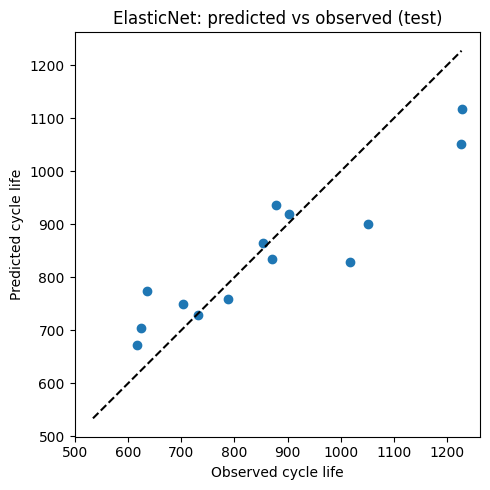

In [11]:
# 예측 vs 실제 (영어 라벨)
plt.figure(figsize=(5, 5))
plt.scatter(y_te, p_enet)
lims = [y.min(), y.max()]; plt.plot(lims, lims, 'k--')
plt.xlabel('Observed cycle life'); plt.ylabel('Predicted cycle life')
plt.title('ElasticNet: predicted vs observed (test)')
plt.tight_layout(); plt.show()

저장 완료


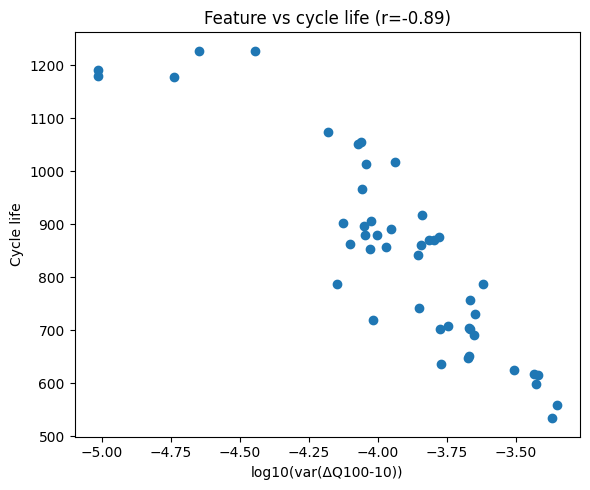

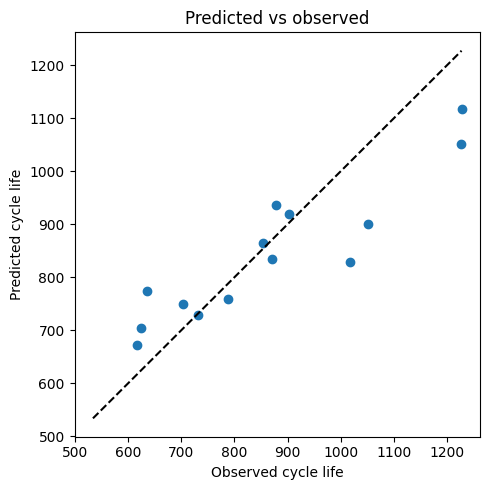

In [12]:
# 핵심 그림 2장 저장 → 왼쪽 📁에서 다운로드
import matplotlib.pyplot as plt
# (1) feature vs 수명
plt.figure(figsize=(6,5)); plt.scatter(feat_logvar, lifes)
plt.xlabel('log10(var(ΔQ100-10))'); plt.ylabel('Cycle life')
plt.title('Feature vs cycle life (r=-0.89)'); plt.tight_layout()
plt.savefig('fig_feature_vs_life.png', dpi=150)
# (2) 예측 vs 실제
plt.figure(figsize=(5,5)); plt.scatter(y_te, p_enet)
lims=[y.min(),y.max()]; plt.plot(lims,lims,'k--')
plt.xlabel('Observed cycle life'); plt.ylabel('Predicted cycle life')
plt.title('Predicted vs observed'); plt.tight_layout()
plt.savefig('fig_pred_vs_obs.png', dpi=150)
print("저장 완료")